In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# --- パラメータ設定 ---
N = 1000  # ノード数
M_BA = 2    # BAモデル: 新規ノードが接続するエッジ数
K_WS = 4    # WSモデル: 各ノードの近傍ノード数
P_WS = 0.1  # WSモデル: エッジを繋ぎ変える確率

# --- 1. バラバシ・アルバート(BA)モデルによるネットワーク生成 ---
G_ba = nx.barabasi_albert_graph(N, M_BA)

# --- 2. ワッツ・ストロガッツ(WS)モデルによるネットワーク生成 ---
G_ws = nx.watts_strogatz_graph(N, K_WS, P_WS)


# --- 3. 統計的特性の計算 ---
def get_network_stats(G, name):
    """ネットワークの統計情報を計算して表示する関数"""
    print(f"--- {name} の統計的特性 ---")
    
    # 次数
    degrees = [d for n, d in G.degree()]
    
    # 平均次数
    avg_degree = np.mean(degrees)
    print(f"平均次数: {avg_degree:.2f}")

    # 平均クラスタリング係数
    avg_clustering = nx.average_clustering(G)
    print(f"平均クラスタリング係数: {avg_clustering:.4f}")

    # 平均経路長 (連結グラフでない場合に備えて最大連結成分で計算)
    if nx.is_connected(G):
        avg_path_length = nx.average_shortest_path_length(G)
        print(f"平均経路長: {avg_path_length:.2f}")
    else:
        # 最大の連結成分を取得
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        avg_path_length = nx.average_shortest_path_length(subgraph)
        print(f"平均経路長 (最大連結成分): {avg_path_length:.2f}")
        
    return degrees

print("生成されたネットワークの統計量を計算します。")
degrees_ba = get_network_stats(G_ba, "BAモデル")
degrees_ws = get_network_stats(G_ws, "WSモデル")


生成されたネットワークの統計量を計算します。
--- BAモデル の統計的特性 ---
平均次数: 3.99
平均クラスタリング係数: 0.0258
平均経路長: 4.11
--- WSモデル の統計的特性 ---
平均次数: 4.00
平均クラスタリング係数: 0.3648
平均経路長: 8.90


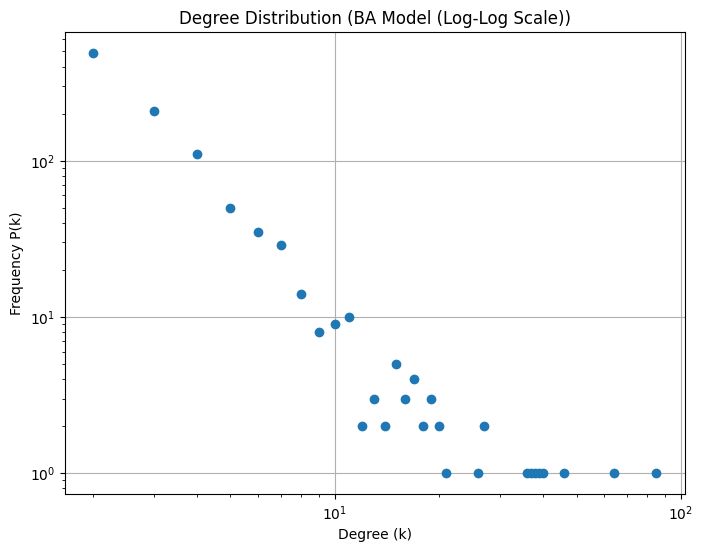

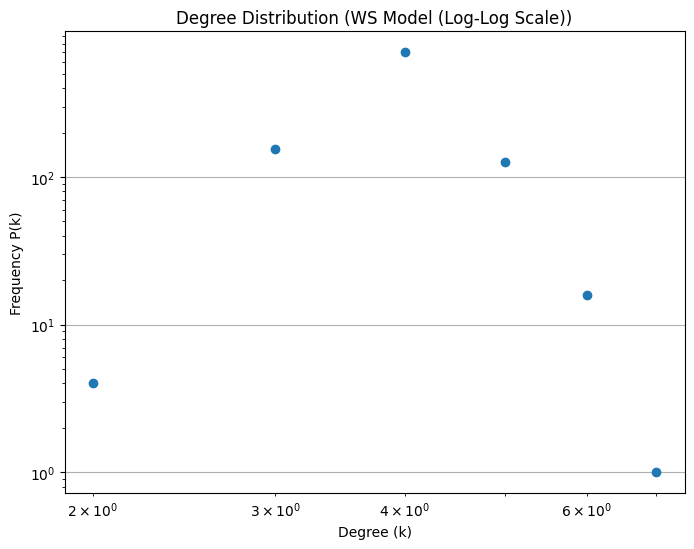

In [2]:
def plot_degree_distribution(degrees, title):
    """次数分布を両対数プロットで描画する関数"""
    hist = nx.degree_histogram(G_ba) # G_baを引数にしていたのを修正
    #次数とその出現頻度を取得
    degree_values = sorted(set(degrees))
    hist = [degrees.count(i) for i in degree_values]
    
    plt.figure(figsize=(8, 6))
    plt.plot(degree_values, hist, 'o')
    plt.title(f'Degree Distribution ({title})')
    plt.xlabel('Degree (k)')
    plt.ylabel('Frequency P(k)')
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True)
    plt.show()

# BAモデルの次数分布をプロット（スケールフリー性の確認）
plot_degree_distribution(degrees_ba, "BA Model (Log-Log Scale)")

# (比較のため)WSモデルの次数分布もプロット
plot_degree_distribution(degrees_ws, "WS Model (Log-Log Scale)")